# Classification Ages: Young vs Old Battery

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).

>
**Expected result:** Given a Nyquist diagram at a certain SOC (chosen by the user or randomly), classify whether the battery is new (Aging 0–2) or old (Aging 3–4).

---

### Difference with the previous notebook (1: LOO)

| | NB1: Leave-One-Out | **NB2: Classification Ages** |
|---|---|---|
| **Type** | Regression | **Classification** |
| **Target** | Z_real, neg_Z_imag | **Young / Old** |
| **Input** | Aging, Temp, SOC, Freq | **Temp, Freq, Z_real, neg_Z_imag** |
| **Challenge** | Predict one graph | **Distinguish aging from the shape of the Nyquist plot** |


> In this task, impedance is the **input** (not the target): the model must infer from the appearance of the Nyquist plot whether the battery is young or old.

# 1. Setup

In [1]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    StratifiedGroupKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#666666",
}

AGING_LABELS = {
    0: "Aging 0 (Fresh)",
    1: "Aging 1",
    2: "Aging 2",
    3: "Aging 3",
    4: "Aging 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

TEMPS_SORTED = sorted(TEMP_COLORS.keys())
AGINGS = list(AGING_LABELS.keys())

CLASS_NAMES = ["Young (Aging 0–2)", "Old (Aging 3–4)"]
CLASS_COLORS = ["#2ecc71", "#e74c3c"]

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )

print_environment_info()

Setup completed
Python 3.12 | NumPy 2.0.1 | Pandas 2.3.3 | Scikit-learn 1.7.1


# 2. Data Loading

In [2]:
# --- LOAD DATASET ---
import pandas as pd
from pathlib import Path

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    import os
    current_dir = Path(os.getcwd())

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

file_path = project_root / "data" / "processed" / "batteries_cleaned_dataset.csv"
print(f"Looking for file at: {file_path}")

if not file_path.exists():
    raise FileNotFoundError(f"CSV file not found at: {file_path}")

df = pd.read_csv(file_path)

# --- CLASSIFICATION LABELS ---
df["Age_class"] = (df["Aging"] >= 3).astype(int)  # 0 = Young, 1 = Old
df["Age_label"] = df["Age_class"].map({0: "Young", 1: "Old"})

# --- DATASET SUMMARY ---
print(f"Dataset: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns")
print(
    f"Agings: {sorted(df['Aging'].unique().tolist())} | "
    f"Temperatures: {sorted(df['Temperature'].unique().tolist())}\u00b0C"
)
print(
    f"SOC levels: {sorted(df['SOC'].unique().tolist())} | "
    f"Frequency range: {df['Frequency'].min():.2f}\u2013{df['Frequency'].max():.0f} Hz"
)

print("\n=== CLASS DISTRIBUTION ===")
young_count = (df["Age_class"] == 0).sum()
old_count = (df["Age_class"] == 1).sum()

print(f"Young (Aging 0\u20132): {young_count:,} samples ({young_count / len(df) * 100:.1f}%)")
print(f"Old   (Aging 3\u20134): {old_count:,} samples ({old_count / len(df) * 100:.1f}%)")


Looking for file at: /Users/davidecorso/Desktop/SUPSI/Progetto_Semestre/git/ml_LiBs_project/data/processed/batteries_cleaned_dataset.csv
Dataset: 9,805 rows × 8 columns
Agings: [0, 1, 2, 3, 4] | Temperatures: [20.0, 22.5, 25.0, 27.5, 30.0, 35.0, 40.0, 47.5]°C
SOC levels: [0, 1, 2, 3, 4] | Frequency range: 0.10–10002 Hz

=== CLASS DISTRIBUTION ===
Young (Aging 0–2): 5,880 samples (60.0%)
Old   (Aging 3–4): 3,925 samples (40.0%)


# 3. EDA: Young vs Old
Let’s analyze whether the classes are visually distinguishable in the Nyquist plots.

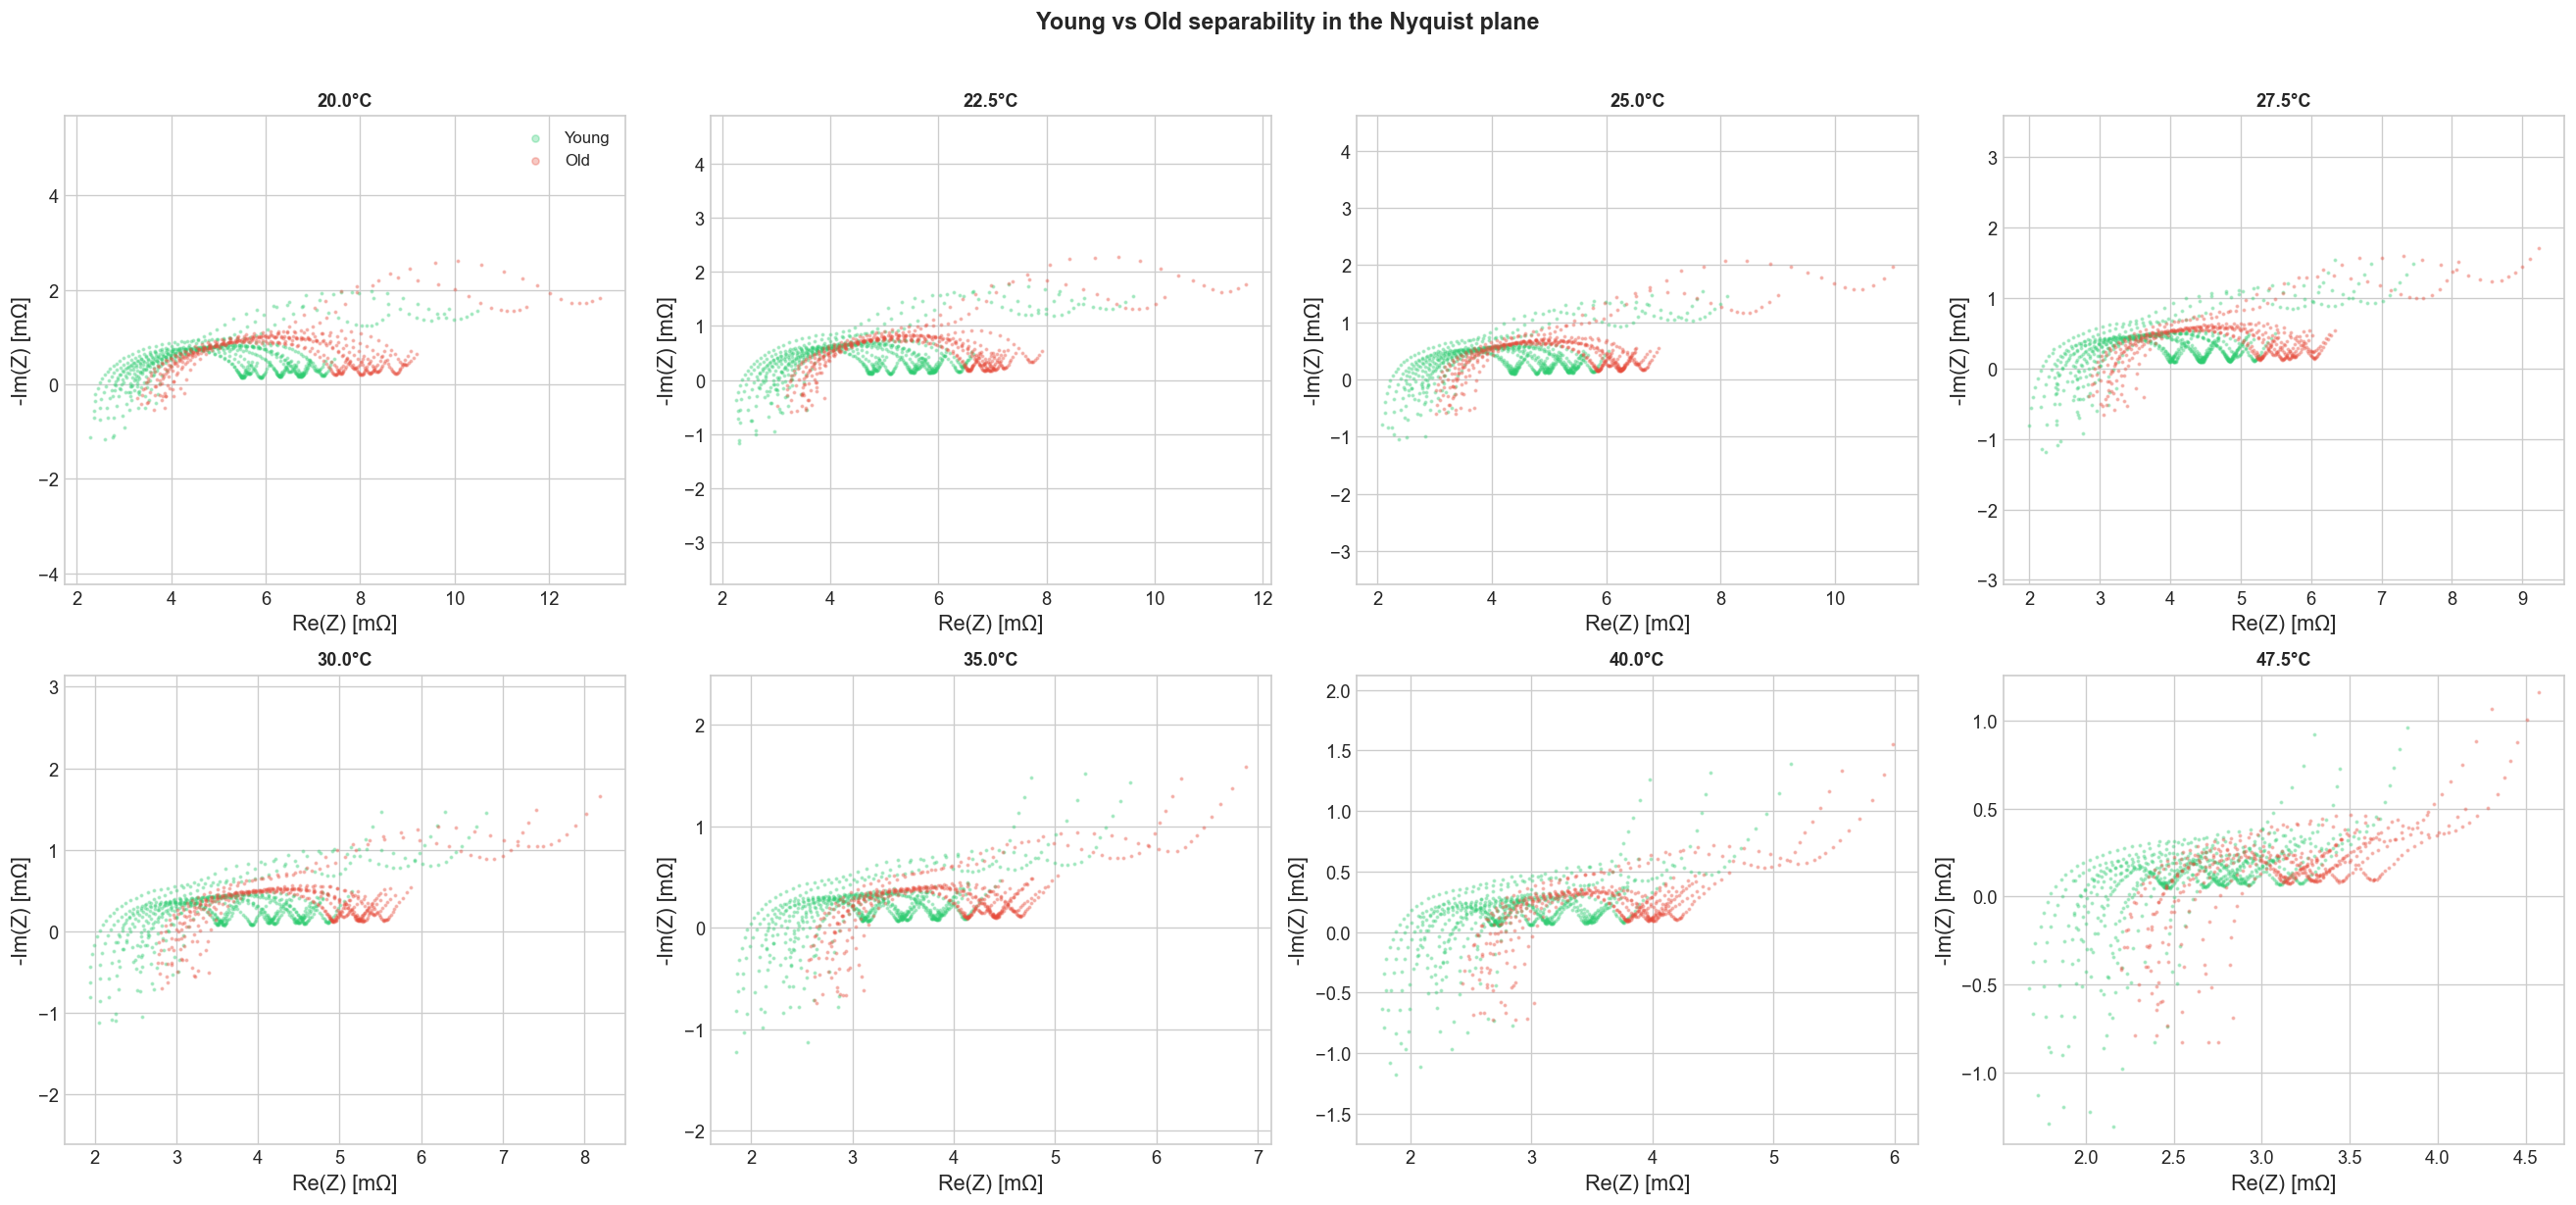

In [3]:
# --- NYQUIST PLOTS BY CLASS (YOUNG vs OLD) ---
# One example per temperature

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes_flat = axes.flatten()

for idx, temp in enumerate(TEMPS_SORTED):
    ax = axes_flat[idx]
    subset = df[df["Temperature"] == temp]

    for cls, color, label in [
        (0, CLASS_COLORS[0], "Young"),
        (1, CLASS_COLORS[1], "Old"),
    ]:
        mask = subset["Age_class"] == cls

        ax.scatter(
            subset.loc[mask, "Z_real"],
            subset.loc[mask, "neg_Z_imag"],
            s=2,
            alpha=0.3,
            color=color,
            label=label,
        )

    ax.set_xlabel("Re(Z) [mΩ]")
    ax.set_ylabel("-Im(Z) [mΩ]")
    ax.set_title(f"{temp}°C", fontsize=11, fontweight="bold")
    ax.set_aspect("equal", adjustable="datalim")

    if idx == 0:
        ax.legend(markerscale=3, fontsize=10)

fig.suptitle(
    "Young vs Old separability in the Nyquist plane",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

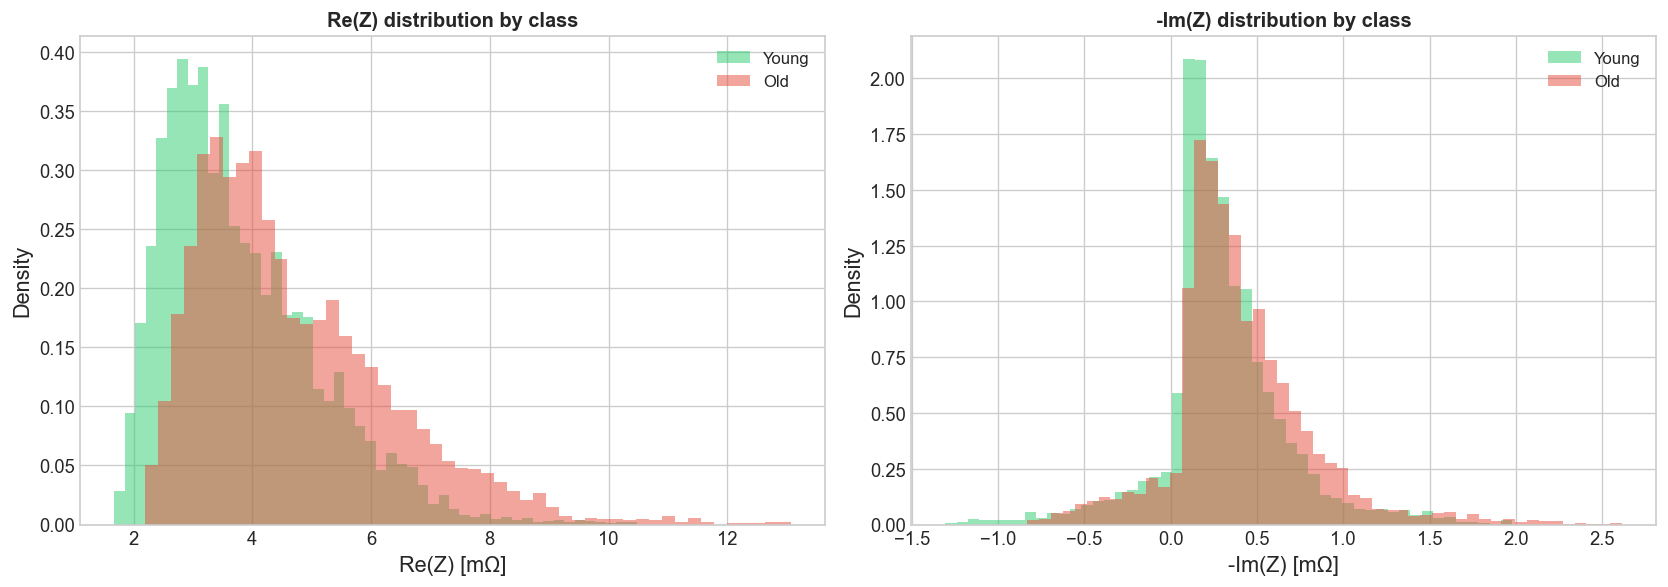

In [4]:
# --- DISTRIBUTION OF Re(Z) AND -Im(Z) BY CLASS ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, label in [
    (0, CLASS_COLORS[0], "Young"),
    (1, CLASS_COLORS[1], "Old"),
]:
    mask = df["Age_class"] == cls

    axes[0].hist(
        df.loc[mask, "Z_real"],
        bins=50,
        alpha=0.5,
        color=color,
        label=label,
        density=True,
    )

    axes[1].hist(
        df.loc[mask, "neg_Z_imag"],
        bins=50,
        alpha=0.5,
        color=color,
        label=label,
        density=True,
    )

axes[0].set_xlabel("Re(Z) [mΩ]")
axes[0].set_ylabel("Density")
axes[0].set_title("Re(Z) distribution by class", fontweight="bold")
axes[0].legend()

axes[1].set_xlabel("-Im(Z) [mΩ]")
axes[1].set_ylabel("Density")
axes[1].set_title("-Im(Z) distribution by class", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

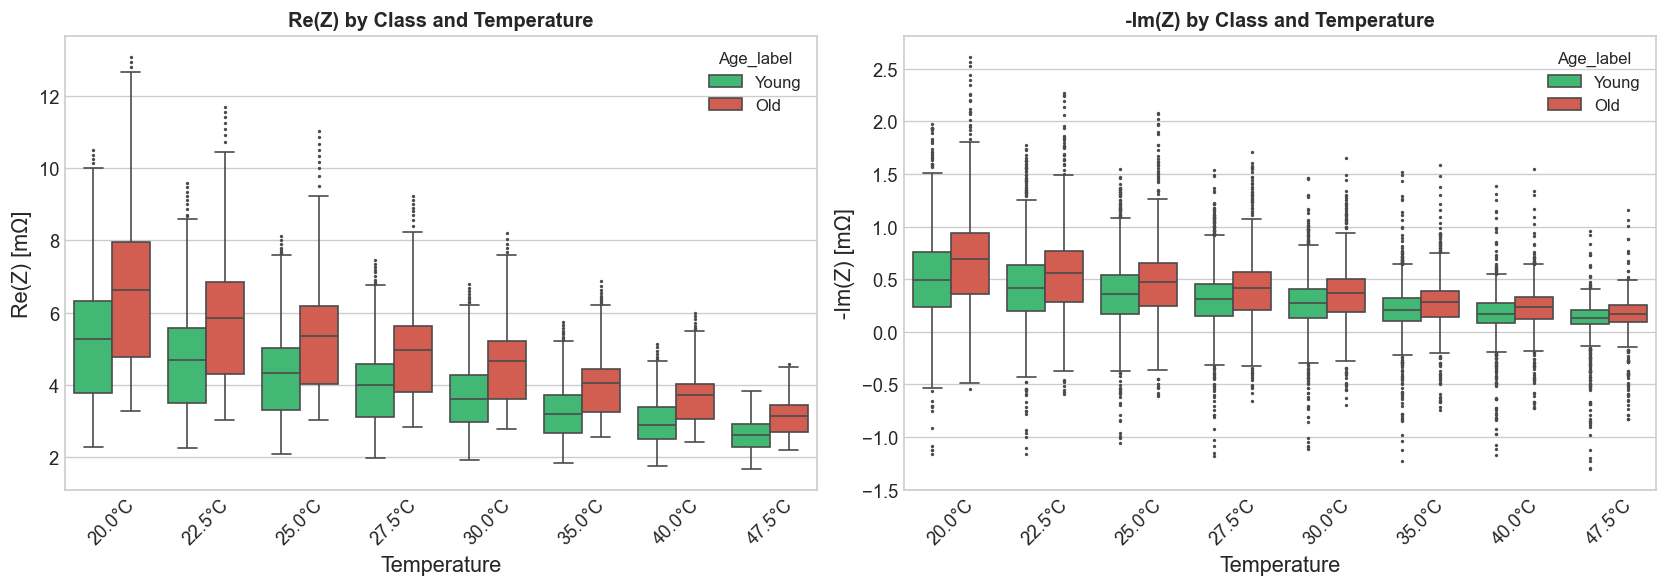

In [5]:
# --- BOX PLOTS BY CLASS AND TEMPERATURE ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df.copy()
df_plot["Temp_str"] = df_plot["Temperature"].astype(str) + "°C"

sns.boxplot(
    data=df_plot,
    x="Temp_str",
    y="Z_real",
    hue="Age_label",
    palette={"Young": CLASS_COLORS[0], "Old": CLASS_COLORS[1]},
    ax=axes[0],
    fliersize=1,
)

axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Re(Z) [mΩ]")
axes[0].set_title("Re(Z) by Class and Temperature", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df_plot,
    x="Temp_str",
    y="neg_Z_imag",
    hue="Age_label",
    palette={"Young": CLASS_COLORS[0], "Old": CLASS_COLORS[1]},
    ax=axes[1],
    fliersize=1,
)

axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("-Im(Z) [mΩ]")
axes[1].set_title("-Im(Z) by Class and Temperature", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 4. SOC Selection

The user selects an SOC level (or randomly). The classifier will be trained and evaluated **only** on that SOC.

This simulates a real-world scenario: you measure impedance at a given SOC and want to determine whether the battery is old or new.

In [6]:
# CONFIGURATION: Choose the selection mode
mode = "random"           # "random" or "manual"
RANDOM_SEED = 42          # Seed for reproducible random selection. Change it to get a different SOC.

MANUAL_SOC = 2            # If mode="manual", specify SOC (0, 1, 2, 3, 4)

available_socs = sorted(df["SOC"].unique())

if mode == "manual":
    assert MANUAL_SOC in available_socs, (
        f"Invalid SOC {MANUAL_SOC}. Available values: {available_socs}"
    )
    SELECTED_SOC = MANUAL_SOC
    print(f"MANUAL mode — Selected SOC: {SELECTED_SOC}")

elif mode == "random":
    np.random.seed(RANDOM_SEED)
    SELECTED_SOC = np.random.choice(available_socs)
    print(f"RANDOM mode — Selected SOC: {SELECTED_SOC} (seed={RANDOM_SEED})")

else:
    raise ValueError(f"Unknown mode '{mode}'.")

# --- FILTER DATA BY SOC ---
df_soc = df[df["SOC"] == SELECTED_SOC].copy()

# --- SUMMARY ---
print(f"\nTotal samples for SOC {SELECTED_SOC}: {len(df_soc):,}")

young_count = (df_soc["Age_class"] == 0).sum()
old_count = (df_soc["Age_class"] == 1).sum()

print(f"Young: {young_count} ({young_count / len(df_soc) * 100:.1f}%)")
print(f"Old:   {old_count} ({old_count / len(df_soc) * 100:.1f}%)")

RANDOM mode — Selected SOC: 3 (seed=42)

Total samples for SOC 3: 1,961
Young: 1176 (60.0%)
Old:   785 (40.0%)


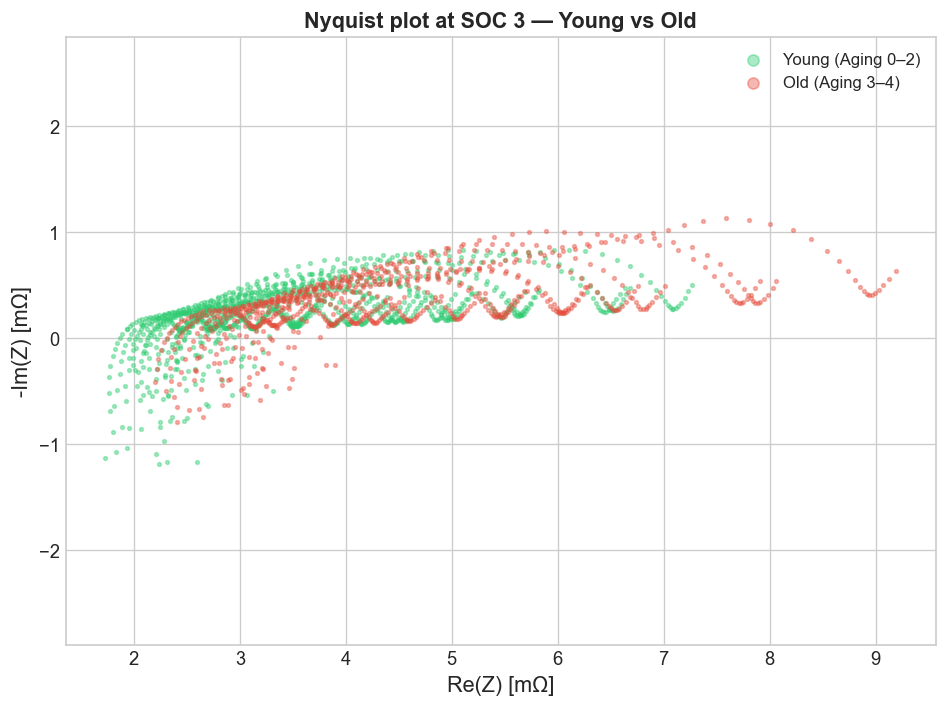

In [7]:
# --- NYQUIST PLOT FOR SELECTED SOC (COLORED BY CLASS) ---

fig, ax = plt.subplots(figsize=(8, 6))

for cls, color, label in [
    (0, CLASS_COLORS[0], "Young (Aging 0–2)"),
    (1, CLASS_COLORS[1], "Old (Aging 3–4)"),
]:
    mask = df_soc["Age_class"] == cls

    ax.scatter(
        df_soc.loc[mask, "Z_real"],
        df_soc.loc[mask, "neg_Z_imag"],
        s=5,
        alpha=0.4,
        color=color,
        label=label,
    )

ax.set_xlabel("Re(Z) [mΩ]")
ax.set_ylabel("-Im(Z) [mΩ]")
ax.set_title(
    f"Nyquist plot at SOC {SELECTED_SOC} — Young vs Old",
    fontsize=13,
    fontweight="bold",
)

ax.legend(markerscale=3)
ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

# 5. Feature Engineering

The features are now the **impedance measurements** themselves, along with temperature and frequency.  

Aging is not used as a feature (it is the variable from which the target is derived).

In [8]:
# --- FEATURE ENGINEERING FOR CLASSIFICATION ---

def build_classification_features(data):
    X = pd.DataFrame({
        "Temperature": data["Temperature"].values,
        "Frequency": data["Frequency"].values,
        "log_Freq": np.log10(data["Frequency"].values),
        "Z_real": data["Z_real"].values,
        "neg_Z_imag": data["neg_Z_imag"].values,
        "Z_magnitude": np.sqrt(
            data["Z_real"].values ** 2 + data["neg_Z_imag"].values ** 2
        ),
        "Z_phase": np.arctan2(
            data["neg_Z_imag"].values,
            data["Z_real"].values
        ),
        "inv_Temp": 1.0 / (data["Temperature"].values + 273.15),
        "Z_real_x_Temp": data["Z_real"].values * data["Temperature"].values,
        "sqrt_Freq": np.sqrt(data["Frequency"].values),
    })
    return X


# --- DATASET PREPARATION ---
X_all = build_classification_features(df_soc)
y_all = df_soc["Age_class"].values

# --- GROUPS FOR LEAKAGE-FREE SPLIT ---
# Each (Aging, Temperature) combination yields ~49 rows (one per frequency)
# sharing the same label. A row-wise random split leaks frequencies of the
# same combination into both train and test, letting the model memorize
# combination signatures instead of learning young/old discrimination.
# Groups keep all rows of a given (Aging, Temperature) together on one side.
groups_all = (
    df_soc["Aging"].astype(str) + "_" + df_soc["Temperature"].astype(str)
).values

# --- TRAIN / TEST SPLIT (STRATIFIED 80/20, GROUP-AWARE) ---
# StratifiedGroupKFold preserves class balance AND respects group boundaries.
# Taking one fold out of 5 yields a ~20% test set with no leakage.
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X_all, y_all, groups=groups_all))

X_train_raw = X_all.iloc[train_idx]
X_test_raw = X_all.iloc[test_idx]
y_train = y_all[train_idx]
y_test = y_all[test_idx]
groups_train = groups_all[train_idx]

# --- STANDARDIZATION ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- SUMMARY ---
print(f"Features ({X_all.shape[1]}): {list(X_all.columns)}\n")

print(
    f"Training: {X_train.shape[0]} samples "
    f"(Young: {(y_train == 0).sum()}, Old: {(y_train == 1).sum()}) | "
    f"Groups: {len(np.unique(groups_train))}"
)

print(
    f"Test:     {X_test.shape[0]} samples "
    f"(Young: {(y_test == 0).sum()}, Old: {(y_test == 1).sum()}) | "
    f"Groups: {len(np.unique(groups_all[test_idx]))}"
)

# --- LEAKAGE CHECK ---
overlap = set(groups_train) & set(groups_all[test_idx])
assert not overlap, f"Group leakage detected: {overlap}"
print(f"\nLeakage check passed: no (Aging, Temperature) group appears in both train and test.")

Features (10): ['Temperature', 'Frequency', 'log_Freq', 'Z_real', 'neg_Z_imag', 'Z_magnitude', 'Z_phase', 'inv_Temp', 'Z_real_x_Temp', 'sqrt_Freq']

Training: 1569 samples (Young: 980, Old: 589) | Groups: 32
Test:     392 samples (Young: 196, Old: 196) | Groups: 8

Leakage check passed: no (Aging, Temperature) group appears in both train and test.


# 6. Multi-Model Training

Comparison between 6 classifiers:

| Model | Type |
|---|---|
| Logistic Regression | Linear |
| Random Forest | Ensemble (bagging) |
| Gradient Boosting | Ensemble (boosting) |
| Extra Trees | Ensemble (bagging) |
| K-Nearest Neighbors | Instance-based |
| SVM (RBF) | Kernel-based |

In [9]:
# --- MODEL DEFINITIONS ---

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=10,
        weights="distance"
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        probability=True,
        random_state=42
    ),
}

# --- STORAGE ---
results = []
predictions = {}
probabilities = {}

# --- TRAINING HEADER ---
print(f"=== TRAINING — SOC Classification {SELECTED_SOC} ===\n")
print(f"{'Model':<25s} {'Accuracy':>9s} {'F1':>6s} {'AUC':>6s} {'Time':>7s}")
print("─" * 57)

# --- TRAINING LOOP ---
for name, model in models.items():

    t0 = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    dt = time.time() - t0

    predictions[name] = y_pred

    # --- PROBABILITIES / SCORES ---
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    probabilities[name] = y_proba

    # --- METRICS ---
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    auc = roc_auc_score(y_test, y_proba)

    # --- CROSS VALIDATION (GROUP-AWARE) ---
    # Same group policy as the train/test split: no (Aging, Temperature)
    # combination can appear on both sides of any CV fold.
    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv,
        scoring="accuracy"
    )

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc,
        "CV_mean": cv_scores.mean(),
        "CV_std": cv_scores.std(),
        "Time_s": dt,
    })

    print(f"{name:<25s} {acc:>9.4f} {f1:>6.4f} {auc:>6.4f} {dt:>6.1f}s")

# --- RESULTS SUMMARY ---
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

best_model_name = results_df.iloc[0]["Model"]

print(
    f"\nBest model: {best_model_name} "
    f"(Acc={results_df.iloc[0]['Accuracy']:.4f})"
)

=== TRAINING — SOC Classification 3 ===

Model                      Accuracy     F1    AUC    Time
─────────────────────────────────────────────────────────
Logistic Regression          0.9541 0.9540 0.9913    0.0s


Random Forest                0.9158 0.9158 0.9711    0.1s


Gradient Boosting            0.9362 0.9362 0.9870    0.3s


Extra Trees                  0.9464 0.9464 0.9893    0.1s
K-Nearest Neighbors          0.9286 0.9285 0.9788    0.0s


SVM (RBF)                    0.9872 0.9872 1.0000    0.1s

Best model: SVM (RBF) (Acc=0.9872)


# 7. Model Comparison

In [10]:
# --- TABLE ---
print("=== RANKING ===\n")

display_df = results_df[
    ["Model", "Accuracy", "F1", "AUC", "CV_mean", "CV_std", "Time_s"]
].copy()

display_df.columns = [
    "Model",
    "Accuracy",
    "F1",
    "AUC",
    "CV_mean",
    "CV_std",
    "Time (s)",
]

print(display_df.to_string(index=False, float_format="{:.4f}".format))

=== RANKING ===

              Model  Accuracy     F1    AUC  CV_mean  CV_std  Time (s)
          SVM (RBF)    0.9872 0.9872 1.0000   0.9654  0.0574    0.0513
Logistic Regression    0.9541 0.9540 0.9913   0.9643  0.0186    0.0062
        Extra Trees    0.9464 0.9464 0.9893   0.7311  0.1438    0.0620
  Gradient Boosting    0.9362 0.9362 0.9870   0.8403  0.1389    0.3107
K-Nearest Neighbors    0.9286 0.9285 0.9788   0.7271  0.1479    0.0035
      Random Forest    0.9158 0.9158 0.9711   0.7796  0.1314    0.1231


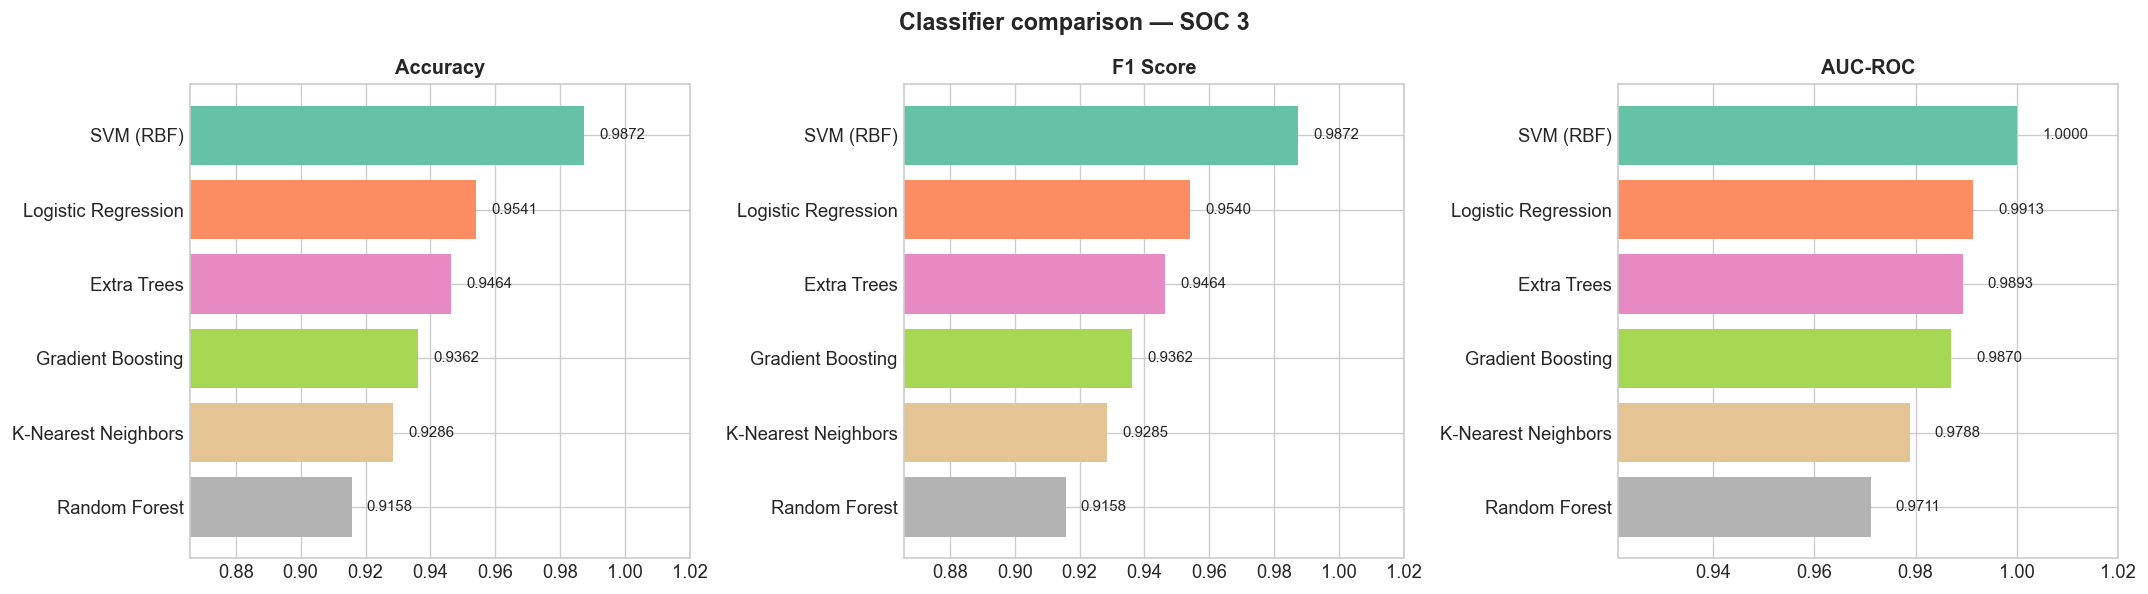

In [11]:
# --- METRICS COMPARISON PLOTS ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for ax, (col, title) in zip(
    axes,
    [("Accuracy", "Accuracy"), ("F1", "F1 Score"), ("AUC", "AUC-ROC")]
):
    bars = ax.barh(
        results_df["Model"].values,
        results_df[col].values,
        color=colors
    )

    ax.set_title(title, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim([max(0, results_df[col].min() - 0.05), 1.02])

    for bar, v in zip(bars, results_df[col].values):
        ax.text(
            bar.get_width() * 1.005,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}",
            va="center",
            fontsize=9
        )

fig.suptitle(
    f"Classifier comparison — SOC {SELECTED_SOC}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 8. Confusion Matrix & ROC Curve

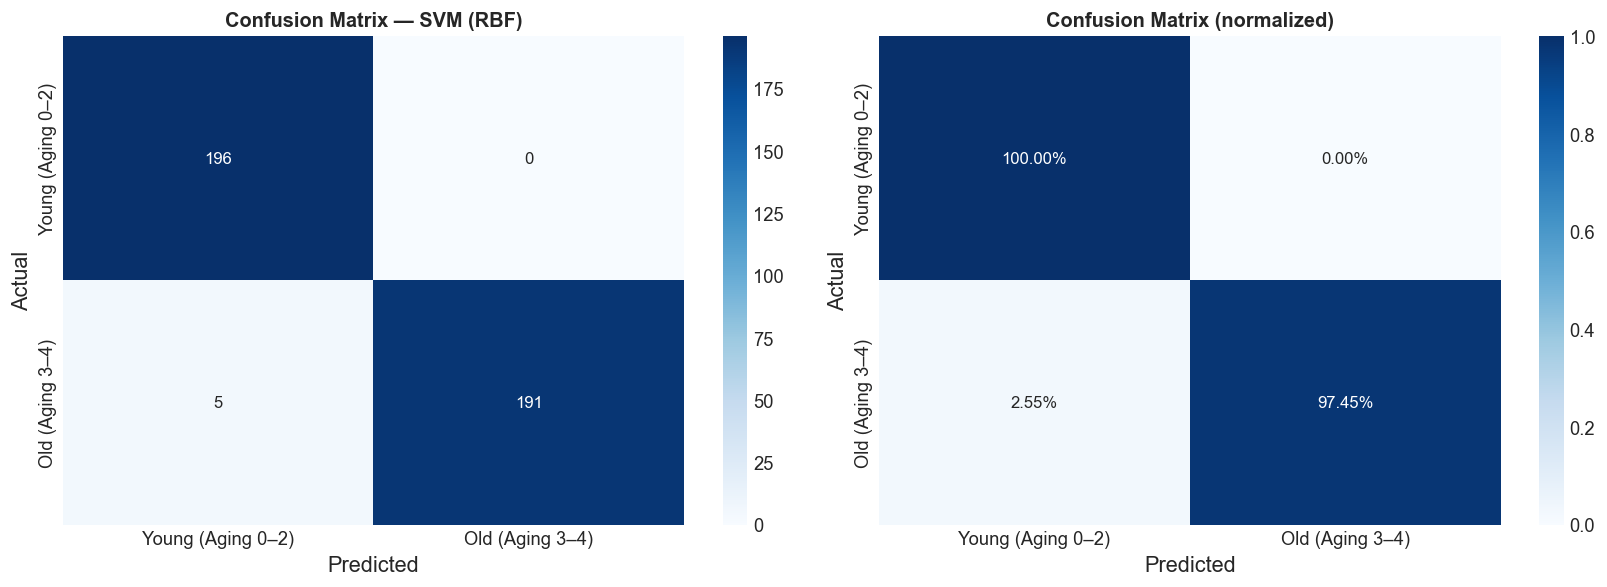


=== CLASSIFICATION REPORT (SVM (RBF)) ===

                   precision    recall  f1-score   support

Young (Aging 0–2)       0.98      1.00      0.99       196
  Old (Aging 3–4)       1.00      0.97      0.99       196

         accuracy                           0.99       392
        macro avg       0.99      0.99      0.99       392
     weighted avg       0.99      0.99      0.99       392



In [12]:
# --- CONFUSION MATRIX FOR BEST MODEL ---

best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- CONFUSION MATRIX (ABSOLUTE) ---
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(
    f"Confusion Matrix — {best_model_name}",
    fontweight="bold"
)

# --- CONFUSION MATRIX (NORMALIZED) ---
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    ax=axes[1],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(
    "Confusion Matrix (normalized)",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# --- CLASSIFICATION REPORT ---
print(f"\n=== CLASSIFICATION REPORT ({best_model_name}) ===\n")

print(
    classification_report(
        y_test,
        best_pred,
        target_names=CLASS_NAMES
    )
)

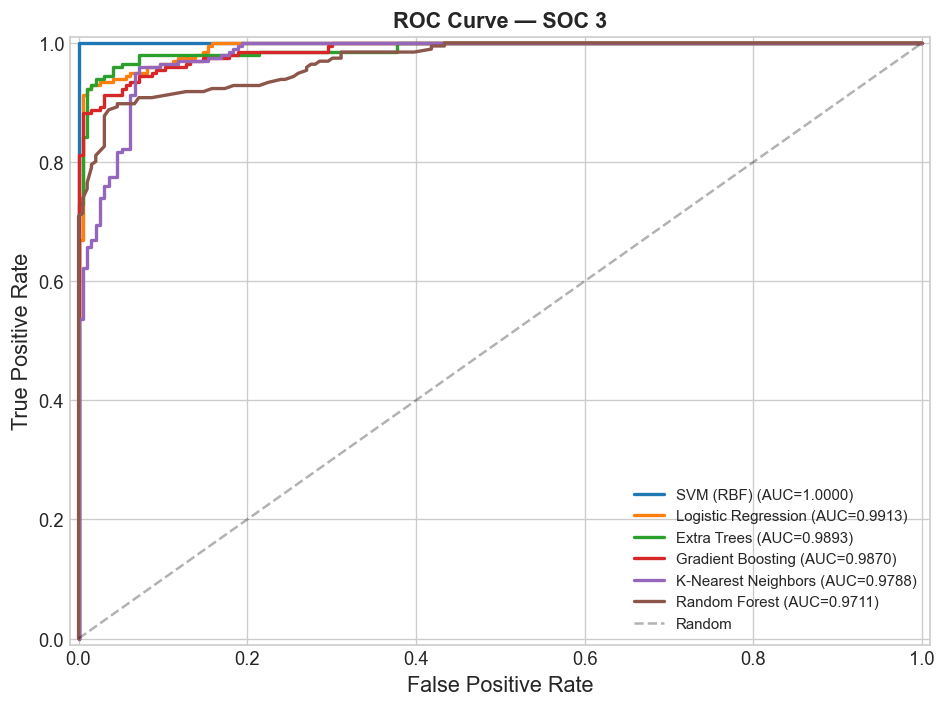

In [13]:
# --- ROC CURVE FOR ALL MODELS ---

fig, ax = plt.subplots(figsize=(8, 6))

for name in results_df["Model"].values:
    y_proba = probabilities[name]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC={auc_val:.4f})"
    )

# --- RANDOM BASELINE ---
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"ROC Curve — SOC {SELECTED_SOC}",
    fontsize=13,
    fontweight="bold"
)

ax.legend(fontsize=9, loc="lower right")

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.show()

# 9. Feature Importance

SVM (RBF) does not provide feature_importances_. Using Random Forest as a proxy.



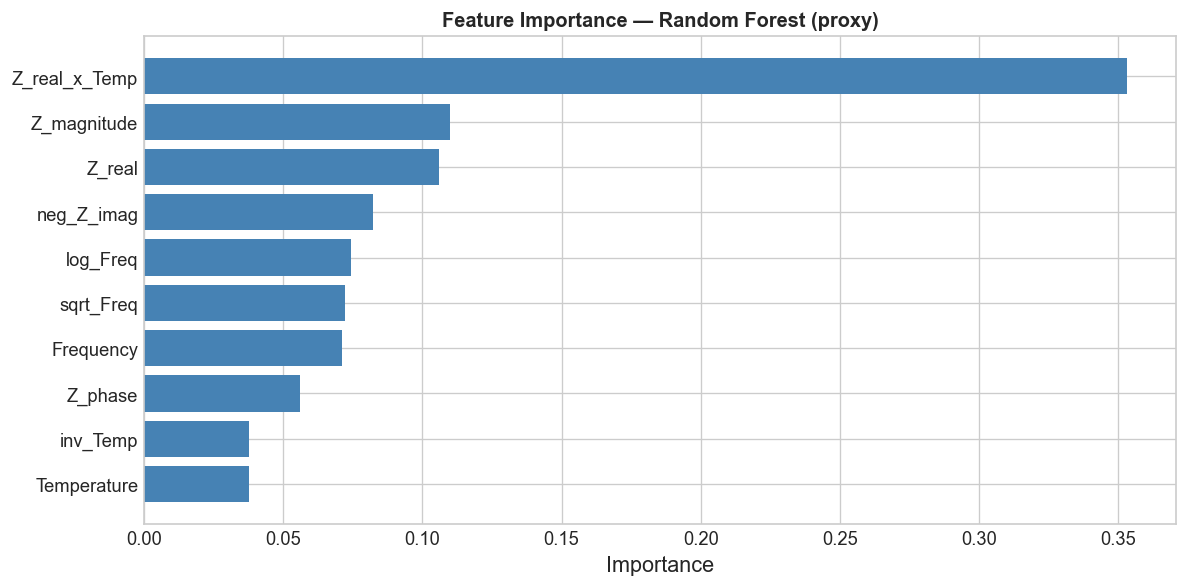


=== TOP FEATURES ===
   Z_real_x_Temp        0.3531
   Z_magnitude          0.1097
   Z_real               0.1058
   neg_Z_imag           0.0822
   log_Freq             0.0743
   sqrt_Freq            0.0721
   Frequency            0.0712
   Z_phase              0.0562
   inv_Temp             0.0378
   Temperature          0.0376


In [14]:
# --- FEATURE IMPORTANCE (BEST MODEL OR PROXY) ---

best_model_obj = models[best_model_name]

if hasattr(best_model_obj, "feature_importances_"):

    importances = best_model_obj.feature_importances_
    feat_names = list(X_all.columns)

    feat_imp_df = pd.DataFrame({
        "Feature": feat_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.barh(
        feat_imp_df["Feature"],
        feat_imp_df["Importance"],
        color="steelblue",
    )

    ax.set_xlabel("Importance")
    ax.set_title(
        f"Feature Importance — {best_model_name}",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("\n=== TOP FEATURES ===")

    for _, row in feat_imp_df.sort_values("Importance", ascending=False).iterrows():
        print(f"   {row['Feature']:20s} {row['Importance']:.4f}")

else:
    # --- USE RANDOM FOREST AS PROXY FOR MODELS WITHOUT FEATURE IMPORTANCE ---
    print(
        f"{best_model_name} does not provide feature_importances_. "
        f"Using Random Forest as a proxy.\n"
    )

    rf_proxy = models.get(
        "Random Forest",
        RandomForestClassifier(n_estimators=100, random_state=42)
    )

    rf_proxy.fit(X_train, y_train)

    importances = rf_proxy.feature_importances_
    feat_names = list(X_all.columns)

    feat_imp_df = pd.DataFrame({
        "Feature": feat_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.barh(
        feat_imp_df["Feature"],
        feat_imp_df["Importance"],
        color="steelblue",
    )

    ax.set_xlabel("Importance")
    ax.set_title(
        "Feature Importance — Random Forest (proxy)",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    print("\n=== TOP FEATURES ===")

    for _, row in feat_imp_df.sort_values("Importance", ascending=False).iterrows():
        print(f"   {row['Feature']:20s} {row['Importance']:.4f}")

# 10. Cross-SOC Analysis

>  How well does the classifier perform across **all** SOC levels? We train on the selected SOC and test on all the others.

In [15]:
# --- CROSS-SOC EVALUATION ---
# Train on selected SOC, test on all SOCs

print(
    f"=== CROSS-SOC: Trained on SOC {SELECTED_SOC}, tested on all ===\n"
)

# --- REUSE BEST MODEL (already fitted in the training loop above) ---
best_model = models[best_model_name]

print(f"{'SOC':>5s} {'Accuracy':>9s} {'F1':>8s} {'N_samples':>10s}")
print("─" * 38)

cross_soc_results = []

for soc in sorted(df["SOC"].unique()):

    df_other = df[df["SOC"] == soc]

    X_other = scaler.transform(
        build_classification_features(df_other)
    )
    y_other = df_other["Age_class"].values

    y_pred_other = best_model.predict(X_other)

    acc = accuracy_score(y_other, y_pred_other)
    f1 = f1_score(y_other, y_pred_other, average="weighted")

    cross_soc_results.append({
        "SOC": soc,
        "Accuracy": acc,
        "F1": f1,
        "N": len(y_other),
    })

    marker = " ← (training SOC)" if soc == SELECTED_SOC else ""

    print(
        f"{soc:>5d} {acc:>9.4f} {f1:>8.4f} {len(y_other):>10d}{marker}"
    )

# --- RESULTS DATAFRAME ---
cross_df = pd.DataFrame(cross_soc_results)

=== CROSS-SOC: Trained on SOC 3, tested on all ===

  SOC  Accuracy       F1  N_samples
──────────────────────────────────────


    0    0.7195   0.7131       1961
    1    0.8710   0.8723       1961
    2    0.9327   0.9332       1961
    3    0.9964   0.9964       1961 ← (training SOC)
    4    0.7792   0.7786       1961


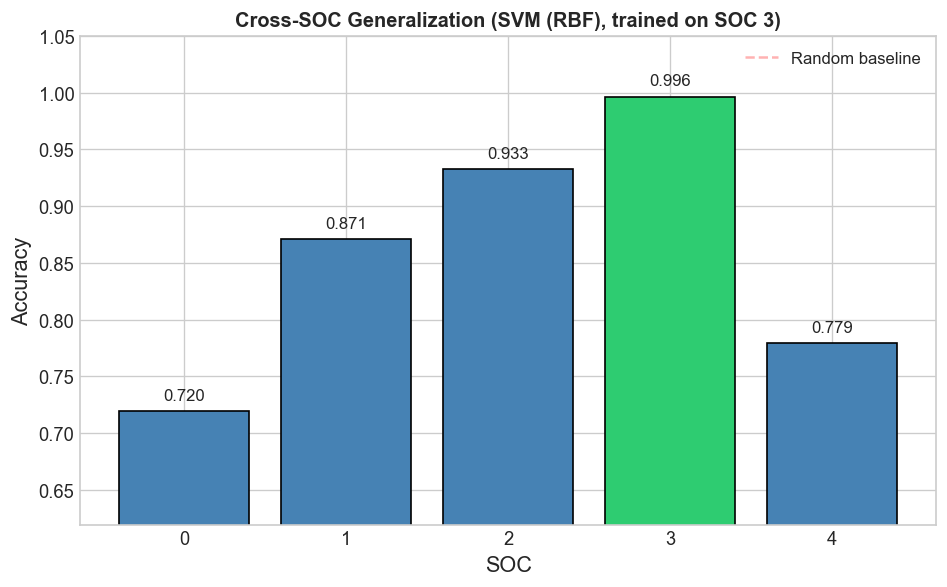

In [16]:
# --- CROSS-SOC PERFORMANCE PLOT ---

fig, ax = plt.subplots(figsize=(8, 5))

colors_bar = [
    "#2ecc71" if s == SELECTED_SOC else "steelblue"
    for s in cross_df["SOC"]
]

ax.bar(
    cross_df["SOC"].astype(str),
    cross_df["Accuracy"],
    color=colors_bar,
    edgecolor="black",
)

ax.set_xlabel("SOC")
ax.set_ylabel("Accuracy")

ax.set_title(
    f"Cross-SOC Generalization ({best_model_name}, trained on SOC {SELECTED_SOC})",
    fontweight="bold",
)

ax.set_ylim([
    max(0, cross_df["Accuracy"].min() - 0.1),
    1.05
])

# --- VALUE LABELS ---
for i, row in cross_df.iterrows():
    ax.text(
        i,
        row["Accuracy"] + 0.01,
        f"{row['Accuracy']:.3f}",
        ha="center",
        fontsize=10,
    )

# --- RANDOM BASELINE ---
ax.axhline(
    y=0.5,
    color="red",
    linestyle="--",
    alpha=0.3,
    label="Random baseline",
)

ax.legend()

plt.tight_layout()
plt.show()

# 11. Hyperparameter Tuning

In [17]:
# --- HYPERPARAMETER TUNING ---

print(f"=== TUNING: {best_model_name} ===\n")

tuning_configs = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 3],
        },
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1],
        },
    },
    "Extra Trees": {
        "model": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [1, 3],
        },
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 10, 15, 25],
            "weights": ["uniform", "distance"],
        },
    },
    "SVM (RBF)": {
        "model": SVC(kernel="rbf", probability=True, random_state=42),
        "params": {
            "C": [1, 10, 100],
            "gamma": ["scale", "auto"],
        },
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
        },
    },
}

config = tuning_configs.get(best_model_name)

if config:

    # --- CROSS-VALIDATION SETUP (GROUP-AWARE) ---
    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    search = GridSearchCV(
        config["model"],
        config["params"],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
    )

    search.fit(X_train, y_train, groups=groups_train)

    print(f"Best params: {search.best_params_}")
    print(f"Best CV accuracy: {search.best_score_:.4f}")

    # --- EVALUATION ON TEST SET ---
    y_pred_tuned = search.best_estimator_.predict(X_test)

    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    acc_orig = results_df.iloc[0]["Accuracy"]

    print(
        f"Original accuracy: {acc_orig:.4f} → "
        f"Tuned accuracy: {acc_tuned:.4f}"
    )

    if acc_tuned > acc_orig:
        print(f"Improvement: +{(acc_tuned - acc_orig) * 100:.2f}%")
    else:
        print("No improvement. Using original model.")

=== TUNING: SVM (RBF) ===



Best params: {'C': 100, 'gamma': 'auto'}
Best CV accuracy: 0.9831
Original accuracy: 0.9872 → Tuned accuracy: 0.9923
Improvement: +0.51%


# 12. Classification Visualization

> We color the Nyquist plot at the selected SOC according to the model predictions.

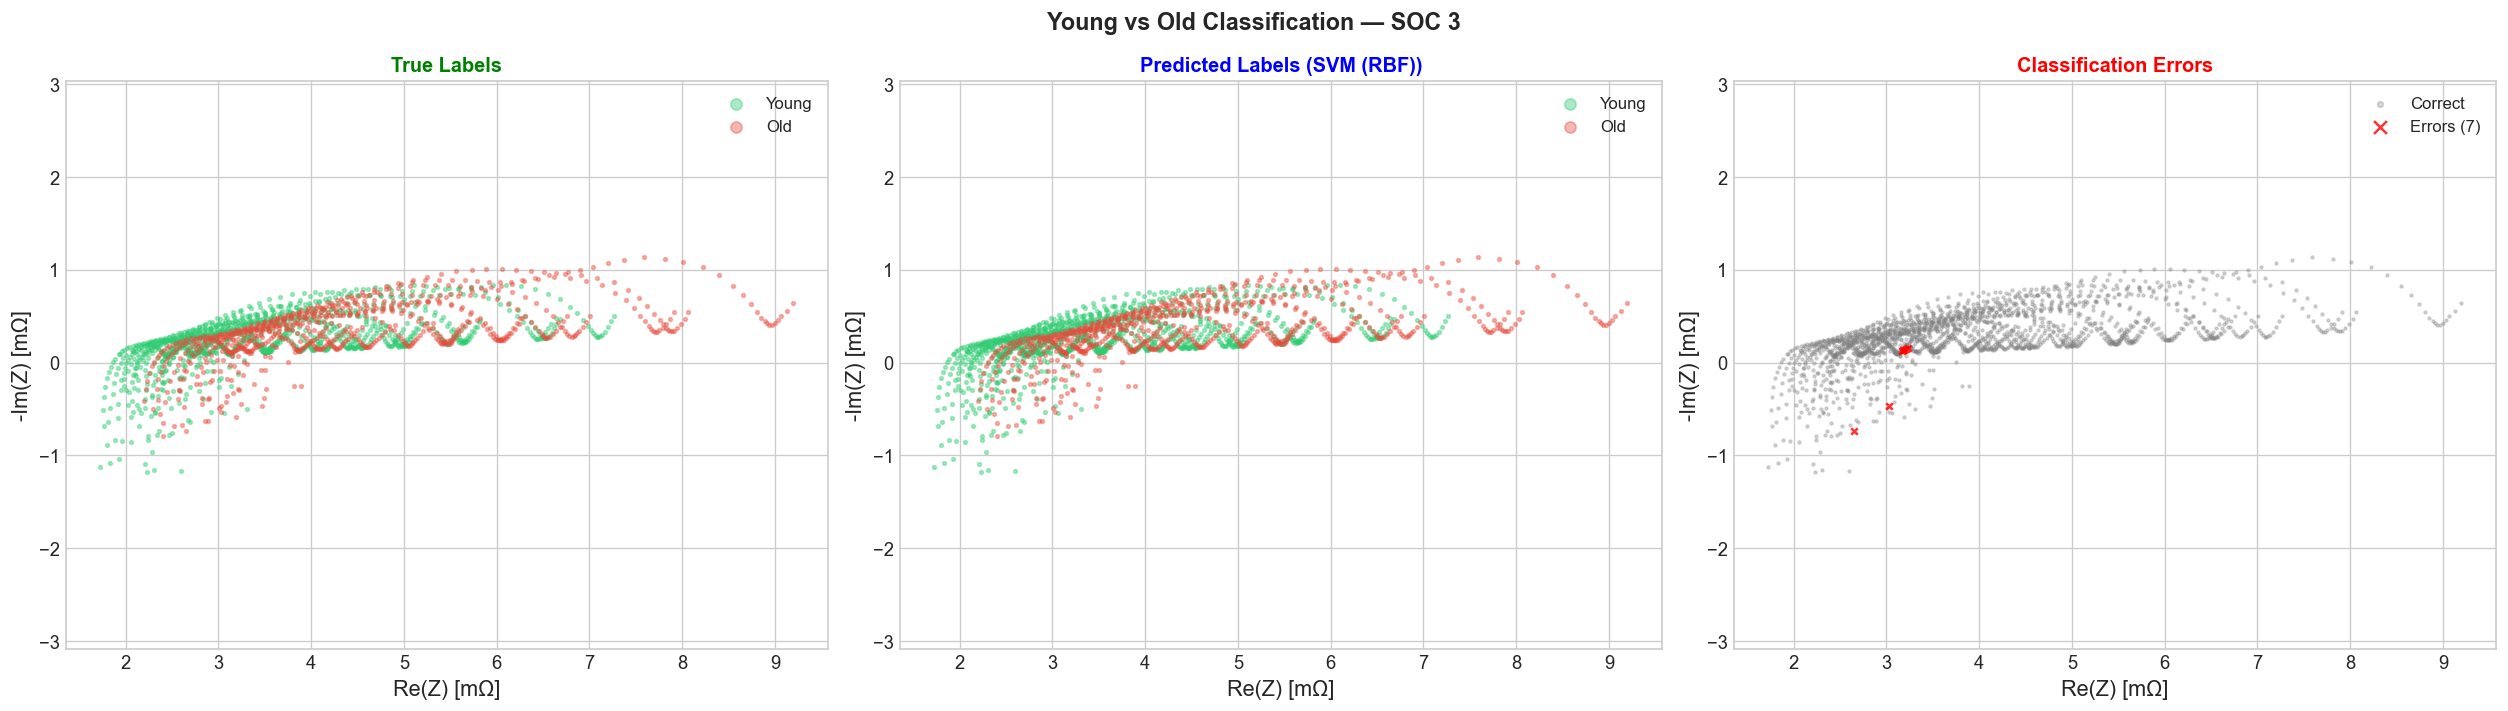

Accuracy on full SOC 3: 0.9964 (7 errors out of 1961)


In [18]:
# --- PREDICTIONS ON FULL SELECTED SOC ---

X_all_scaled = scaler.transform(X_all)
y_pred_all = models[best_model_name].predict(X_all_scaled)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- TRUE LABELS ---
ax = axes[0]

for cls, color, label in [
    (0, CLASS_COLORS[0], "Young"),
    (1, CLASS_COLORS[1], "Old"),
]:
    mask = y_all == cls

    ax.scatter(
        df_soc.iloc[mask]["Z_real"],
        df_soc.iloc[mask]["neg_Z_imag"],
        s=5,
        alpha=0.4,
        color=color,
        label=label,
    )

ax.set_title("True Labels", fontweight="bold", color="green")
ax.legend(markerscale=3)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("Re(Z) [mΩ]")
ax.set_ylabel("-Im(Z) [mΩ]")

# --- PREDICTED LABELS ---
ax = axes[1]

for cls, color, label in [
    (0, CLASS_COLORS[0], "Young"),
    (1, CLASS_COLORS[1], "Old"),
]:
    mask = y_pred_all == cls

    ax.scatter(
        df_soc.iloc[mask]["Z_real"].values,
        df_soc.iloc[mask]["neg_Z_imag"].values,
        s=5,
        alpha=0.4,
        color=color,
        label=label,
    )

ax.set_title(
    f"Predicted Labels ({best_model_name})",
    fontweight="bold",
    color="blue",
)

ax.legend(markerscale=3)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("Re(Z) [mΩ]")
ax.set_ylabel("-Im(Z) [mΩ]")

# --- CLASSIFICATION ERRORS ---
ax = axes[2]

correct = y_pred_all == y_all

ax.scatter(
    df_soc.iloc[correct.astype(bool)]["Z_real"].values,
    df_soc.iloc[correct.astype(bool)]["neg_Z_imag"].values,
    s=3,
    alpha=0.3,
    color="gray",
    label="Correct",
)

wrong_mask = ~correct.astype(bool)

if wrong_mask.sum() > 0:
    ax.scatter(
        df_soc.iloc[wrong_mask]["Z_real"].values,
        df_soc.iloc[wrong_mask]["neg_Z_imag"].values,
        s=15,
        alpha=0.8,
        color="red",
        marker="x",
        label=f"Errors ({wrong_mask.sum()})",
    )

ax.set_title(
    "Classification Errors",
    fontweight="bold",
    color="red",
)

ax.legend(markerscale=2)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("Re(Z) [mΩ]")
ax.set_ylabel("-Im(Z) [mΩ]")

# --- GLOBAL TITLE ---
fig.suptitle(
    f"Young vs Old Classification — SOC {SELECTED_SOC}",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# --- FINAL METRIC ---
acc_all = accuracy_score(y_all, y_pred_all)

print(
    f"Accuracy on full SOC {SELECTED_SOC}: "
    f"{acc_all:.4f} ({wrong_mask.sum()} errors out of {len(y_all)})"
)

# 13. Conclusions

## Pipeline — Classification Ages (Young vs Old)

1. **Setup** — import of libraries.
2. **Data loading** — reading `batteries_cleaned_dataset.csv` from `data/processed/`, deriving the binary target `Age_class` (Young: Aging 0–2, Old: Aging 3–4).
3. **EDA: Young vs Old** — 2×4 grid of Nyquist plots per temperature colored by class, `Z_real`/`neg_Z_imag` histograms by class, and boxplots of `Z_real`/`neg_Z_imag` per Temperature with class as hue, to visually assess separability.
4. **SOC selection** — configurable mode (`random` or `manual`): one SOC level is selected, and all subsequent training/testing is restricted to that SOC; the selected Nyquist plot is shown colored by class.
5. **Feature engineering** — 10 features where impedance is now the **input** (not the target): `Temperature`, `Frequency`, `log_Freq`, `Z_real`, `neg_Z_imag`, `Z_magnitude`, `Z_phase`, `inv_Temp` (Arrhenius term), `Z_real_x_Temp`, `sqrt_Freq`; `Aging` is excluded (it defines the target). Both `X_train` and `X_test` standardized via `StandardScaler` fitted on training only.
6. **Multi-model training** — 6 classifiers: Logistic Regression, Random Forest, Gradient Boosting, Extra Trees, KNN, SVM (RBF); evaluation via Accuracy, F1, AUC and 5-fold group-aware cross-validation (`StratifiedGroupKFold` on `(Aging, Temperature)`) for honest mean/std.
7. **Model comparison** — ranking table and 3-panel horizontal bar charts for Accuracy, F1 and AUC-ROC.
8. **Confusion matrix & ROC curve** — absolute and normalized confusion matrices for the best model, plus overlaid ROC curves for all models with a random-baseline diagonal.
9. **Feature importance** — visualization of `feature_importances_` from tree-based models (or Random Forest as proxy for non-tree models), ranked by magnitude.
10. **Cross-SOC analysis** — best model trained on the selected SOC and evaluated on all other SOCs to test generalization; bar chart with the training SOC highlighted.
11. **Hyperparameter tuning** — `GridSearchCV` on the best-ranked model, with a model-specific parameter grid. Cross-validation uses `StratifiedGroupKFold` with `(Aging, Temperature)` as groups, matching the train/test split policy.
12. **Classification visualization** — Nyquist plot at the selected SOC colored by model predictions, compared against the true labels.

## Comparison with NB1 and NB3

| Metric | Leave-One-Out (NB1) | Classification Ages (NB2) | Aging Interpolation (NB3) |
|---|---|---|---|
| Task | Regression | Classification | Regression |
| Target | Z_real, neg_Z_imag | Young vs Old | Z_real, neg_Z_imag |
| Data excluded | ~245 points (1/40) | 20% group-aware split (`StratifiedGroupKFold`) | ~1960 points — 40 Nyquist plots (1/5) |
| Models benchmarked | 5 | 6 | 5 |
| Difficulty | Medium | Low | **High** |